In [211]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image, ImageDraw

In [213]:
# Parameters
nx, ny = 200, 100  # Grid size
tau = 0.8  # Relaxation time
omega = 1 / tau  # Collision frequency
iterations = 500  # Number of iterations
obstacle_radius = 10  # Obstacle radius
obstacle_x, obstacle_y = nx // 4, ny // 2  # Obstacle position
u_max = 0.1  # Maximum velocity at the inlet
rho0 = 1.0  # Initial density
specific_heat_capacity = 1.0  # Specific heat capacity (assumed constant)

# Lattice velocities and weights
c = np.array([[0, 0], [1, 0], [0, 1], [-1, 0], [0, -1], [1, 1], [-1, 1], [-1, -1], [1, -1]])
w = np.array([4 / 9] + [1 / 9] * 4 + [1 / 36] * 4)

In [215]:
def initialize():
    f = np.ones((9, nx, ny)) * rho0 / 9
    feq = np.zeros_like(f)
    rho = np.ones((nx, ny)) * rho0
    u = np.zeros((2, nx, ny))
    temp = np.ones((nx, ny)) * 300  # Initial temperature (in K)
    obstacle = np.fromfunction(lambda x, y: (x - obstacle_x) ** 2 + (y - obstacle_y) ** 2 <= obstacle_radius ** 2, (nx, ny))
    u[0, 0, :] = u_max
    return f, feq, rho, u, obstacle, temp

def equilibrium_distribution(u, rho):
    u_dot_c = u[0] * c[:, 0].reshape(-1, 1, 1) + u[1] * c[:, 1].reshape(-1, 1, 1)
    u_sq = u[0] ** 2 + u[1] ** 2
    feq = np.einsum('i,jk->ijk', w, rho) * (1 + 3 * u_dot_c + 9 / 2 * u_dot_c ** 2 - 3 / 2 * u_sq)
    return feq

def collision(f, feq):
    return (1 - omega) * f + omega * feq

def streaming(f):
    for i, ci in enumerate(c):
        f[i] = np.roll(f[i], shift=ci, axis=(0, 1))
    return f

def macroscopic_variables(f):
    rho = np.sum(f, axis=0)
    u = np.zeros((2, nx, ny))
    u[0] = np.einsum('i,ijk->jk', c[:, 0], f) / rho
    u[1] = np.einsum('i,ijk->jk', c[:, 1], f) / rho
    return rho, u

def create_gif(images, gif_name='lbm_simulation.gif'):
    images[0].save(gif_name, save_all=True, append_images=images[1:], duration=100, loop=0)

def run_simulation():
    f, feq, rho, u, obstacle, temp = initialize()
    images = []
    velocities = []

    for it in range(iterations):
        feq = equilibrium_distribution(u, rho)
        f = collision(f, feq)
        f = streaming(f)
        f = apply_boundary_conditions(f, feq, obstacle)
        rho, u = macroscopic_variables(f)
        u[:, obstacle] = 0

        if it % 10 == 0:  # Save every 10 iterations
            velocity_magnitude = np.sqrt(u[0] ** 2 + u[1] ** 2).T
            velocities.append(velocity_magnitude)

            img = Image.new('RGB', (ny, nx))  # Fixing the dimensions here
            draw = ImageDraw.Draw(img)

            for x in range(nx):
                for y in range(ny):
                    value = velocity_magnitude[y, x]  # Swapping indices
                    r = int(255 * value / np.max(velocity_magnitude))
                    b = 255 - r
                    g = 0
                    draw.point((y, x), fill=(r, g, b))  # Swapping indices

            images.append(img)

    create_gif(images)
    return np.array(velocities), rho

def plot_3d_velocity(velocities):
    X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
    Z = velocities[-1]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='coolwarm')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Velocity Magnitude')
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, pad=0.2)  # Adding color bar
    plt.savefig('3d_velocity.png')  # Save the plot
    plt.show()


def plot_velocity_over_time(velocities, x, y):
    times = np.arange(0, len(velocities))  # Creating time points
    speeds = [velocities[t][y, x] for t in times]  # Extracting speeds at (x, y) over time
    
    plt.figure()
    plt.plot(times, speeds, label='Velocity')
    plt.xlabel('Time (frames)')
    plt.ylabel('Velocity Magnitude')
    plt.title(f'Velocity over Time at Point ({x}, {y})')
    plt.legend()
    plt.savefig('velocity_over_time.png')  # Save the plot
    plt.show()


def calculate_temperatures(velocities, rho0, specific_heat_capacity):
    temperatures = []
    for velocity_magnitude in velocities:
        kinetic_energy = 0.5 * rho0 * velocity_magnitude ** 2
        temperature = kinetic_energy / (specific_heat_capacity * rho0)
        temperatures.append(temperature)
    return temperatures


In [216]:
def apply_boundary_conditions(f, feq, obstacle):
    for i, ci in enumerate(c):
        f[i, obstacle] = f[(i + 4) % 8, obstacle]
    f[1, 0, :] = feq[1, 0, :] + f[3, 0, :] - feq[3, 0, :]
    f[5, 0, :] = feq[5, 0, :] + f[7, 0, :] - feq[7, 0, :]
    f[8, 0, :] = feq[8, 0, :] + f[6, 0, :] - feq[6, 0, :]
    f[3, -1, :] = f[3, -2, :]
    f[6, -1, :] = f[6, -2, :]
    f[7, -1, :] = f[7, -2, :]
    return f

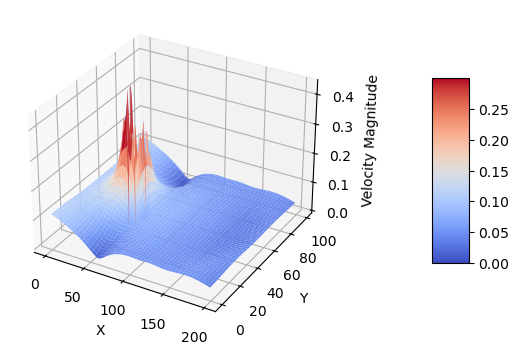

In [218]:
velocities, rho = run_simulation()  # اجرای شبیه‌سازی و دریافت سرعت‌ها و چگالی
temperatures = calculate_temperatures(velocities, rho0, specific_heat_capacity)
plot_3d_velocity(velocities)

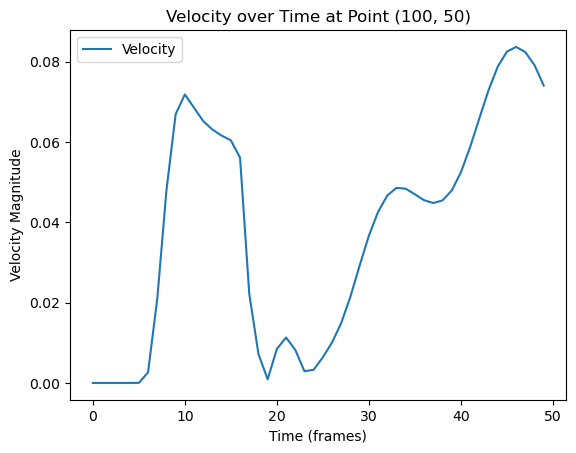

In [219]:
plot_velocity_over_time(velocities, x=100, y=50)  # مثال برای نقطه (100, 50)

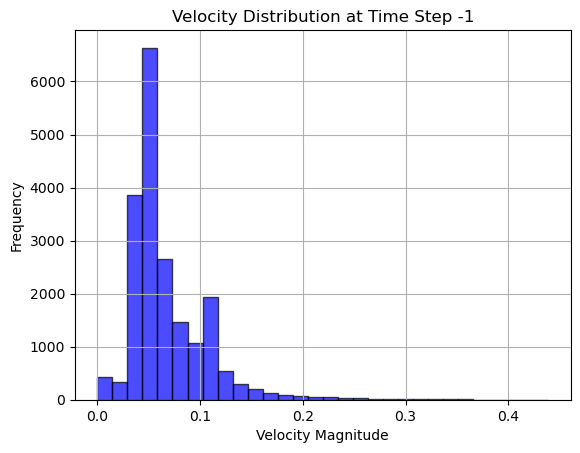

In [221]:
def plot_velocity_distribution(velocities, time_step=-1):
    velocity_magnitudes = velocities[time_step].flatten()

    plt.figure()
    plt.hist(velocity_magnitudes, bins=30, color='blue', alpha=0.7, edgecolor='black')
    plt.xlabel('Velocity Magnitude')
    plt.ylabel('Frequency')
    plt.title(f'Velocity Distribution at Time Step {time_step}')
    plt.grid(True)
    plt.savefig('velocity_distribution.png')  # Save the plot
    plt.show()

plot_velocity_distribution(velocities, time_step=-1)

In [222]:
def calculate_kinetic_energy(velocities, rho0):
    kinetic_energy = []

    for t in range(len(velocities)):
        velocity_magnitude = velocities[t]
        kinetic = 0.5 * rho0 * np.sum(velocity_magnitude ** 2)
        kinetic_energy.append(kinetic)
    
    return kinetic_energy


def plot_kinetic_energy(kinetic_energy):
    times = np.arange(len(kinetic_energy))
    plt.figure()
    plt.plot(times, kinetic_energy, label='Kinetic Energy', color='b')
    plt.xlabel('Time Steps')
    plt.ylabel('Energy')
    plt.title('Kinetic Energy Over Time')
    plt.legend()
    plt.grid(True)
    plt.savefig('kinetic_energy.png')  
    plt.show()

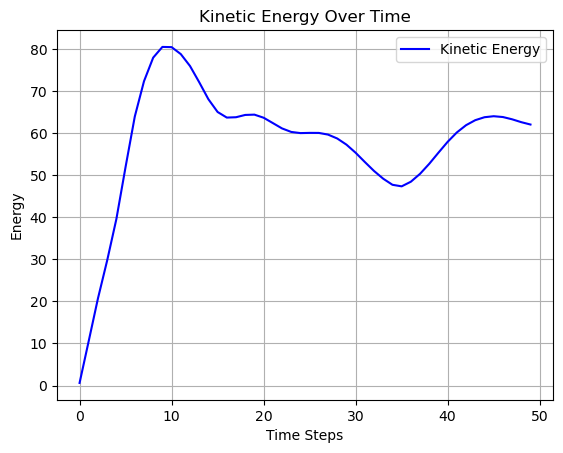

In [223]:
# محاسبه و رسم انرژی‌ها با احتساب انرژی گرمایی
kinetic_energy= calculate_kinetic_energy(velocities,rho0)
plot_kinetic_energy(kinetic_energy)

In [224]:
def plot_3d_temperature(temperatures):
    X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
    Z = temperatures[-1]  # استفاده از آخرین تایم استپ برای رسم

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='hot')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Temperature')

    # افزودن رنگ‌آمیزی و تنظیم موقعیت
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, pad=0.2)
    cbar.set_label('Temperature')  # افزودن برچسب به رنگ‌آمیزی
    
    plt.savefig('3d_temperature.png')  # ذخیره نمودار
    plt.show()

def plot_temperature_distribution(temperatures, time_step=-1):
    temperature_values = temperatures[time_step].flatten()

    plt.figure()
    plt.hist(temperature_values, bins=30, color='red', alpha=0.7, edgecolor='black')
    plt.xlabel('Temperature')
    plt.ylabel('Frequency')
    plt.title(f'Temperature Distribution at Time Step {time_step}')
    plt.grid(True)
    plt.savefig('temperature_distribution.png')  # Save the plot
    plt.show()


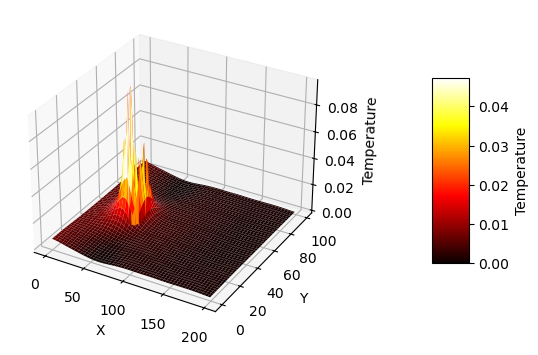

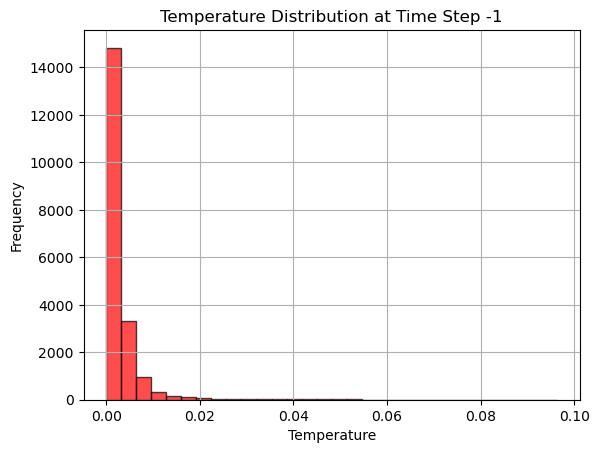

In [225]:
# رسم توزیع دما و دمای سه‌بعدی
plot_3d_temperature(temperatures)
plot_temperature_distribution(temperatures, time_step=-1)

In [226]:
######## بدون مانع

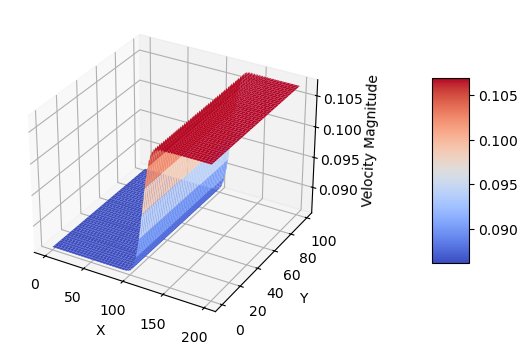

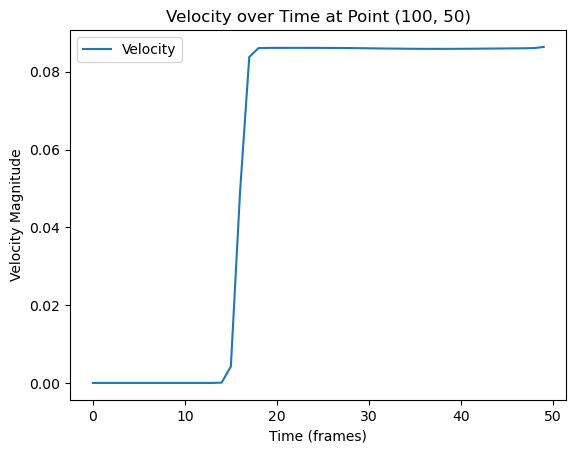

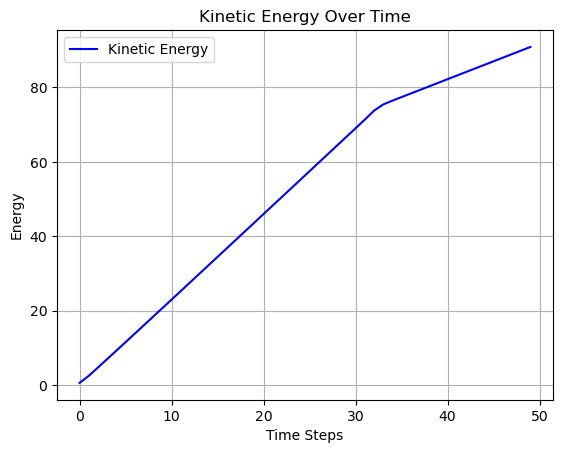

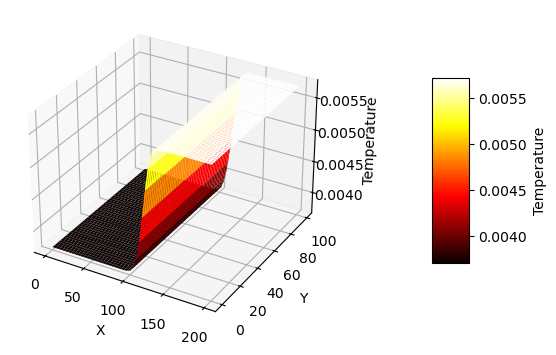

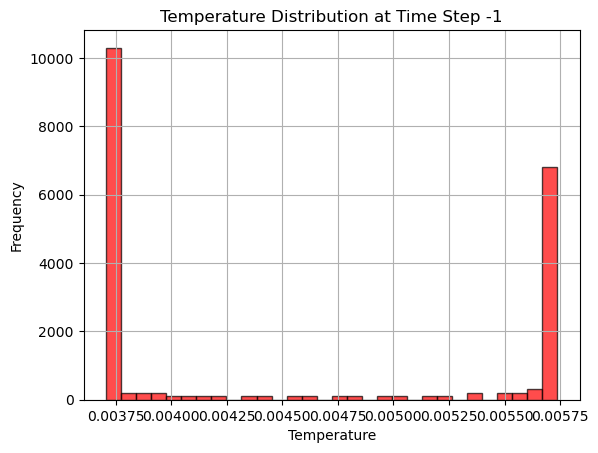

In [227]:
def initialize():
    f = np.ones((9, nx, ny)) * rho0 / 9
    feq = np.zeros_like(f)
    rho = np.ones((nx, ny)) * rho0
    u = np.zeros((2, nx, ny))
    temp = np.ones((nx, ny)) * 300  # Initial temperature (in K)
    obstacle = np.zeros((nx, ny), dtype=bool)  # ایجاد ماسک خالی برای مانع
    u[0, 0, :] = u_max
    return f, feq, rho, u, obstacle, temp


if __name__ == "__main__":
    velocities, rho = run_simulation()  # اجرای شبیه‌سازی و دریافت سرعت‌ها و چگالی
    temperatures = calculate_temperatures(velocities, rho0, specific_heat_capacity)
    
    plot_3d_velocity(velocities)
    plot_velocity_over_time(velocities, x=100, y=50)  # مثال برای نقطه (100, 50)
    
    # محاسبه و رسم انرژی جنبشی
    kinetic_energy = calculate_kinetic_energy(velocities, rho0)
    plot_kinetic_energy(kinetic_energy)
    
    # رسم توزیع دما و دمای سه‌بعدی
    plot_3d_temperature(temperatures)
    plot_temperature_distribution(temperatures, time_step=-1)  # مثال برای آخرین تایم استپ